# Baseline CNN

A small convolutional network trained from scratch: 4 conv blocks
(Conv2D x2 -> MaxPooling -> Dropout, doubling filters each block), then a
dense head. The point of this notebook is a *correct* baseline before
touching class imbalance or transfer learning - every image is verified
against its label before training, one model object is trained and that
exact object is what gets evaluated, and evaluation is per-class, not just
one overall accuracy number.

In [1]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, f1_score

np.random.seed(42)
tf.random.set_seed(42)

data = np.load('data/dermamnist_128.npz')
X_train = data['train_images'].astype('float32') / 255.0
y_train = data['train_labels'].ravel()
X_val = data['val_images'].astype('float32') / 255.0
y_val = data['val_labels'].ravel()
X_test = data['test_images'].astype('float32') / 255.0
y_test = data['test_labels'].ravel()

class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

X_train.shape, X_val.shape, X_test.shape

I0000 00:00:1785462167.646458  505459 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785462167.686667  505459 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785462169.113489  505459 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


((7007, 128, 128, 3), (1003, 128, 128, 3), (2005, 128, 128, 3))

Image/label alignment check - the point this notebook exists to get right. Pulling a handful of images straight from the arrays and eyeballing them against their label, plus a hard shape assertion, before any training happens.

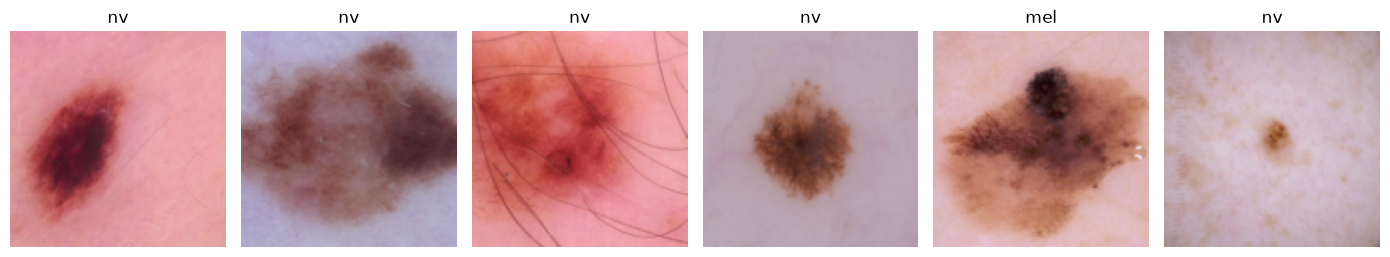

In [2]:
assert X_train.shape[0] == y_train.shape[0]
assert X_val.shape[0] == y_val.shape[0]
assert X_test.shape[0] == y_test.shape[0]

fig, axes = plt.subplots(1, 6, figsize = (14, 3))
rng = np.random.RandomState(0)
for ax, idx in zip(axes, rng.choice(len(X_train), 6, replace = False)):
    ax.imshow(X_train[idx])
    ax.set_title(class_names[y_train[idx]])
    ax.axis('off')
plt.tight_layout()
plt.show()

Majority-class baseline - the number any model has to beat to be doing something other than memorizing which class is most common.

In [3]:
majority_class = pd.Series(y_train).value_counts().idxmax()
majority_baseline_acc = (y_test == majority_class).mean()
print(f'majority class: {class_names[majority_class]}')
print(f'always predicting it on the test set: {majority_baseline_acc:.4f} accuracy')

majority class: nv
always predicting it on the test set: 0.6688 accuracy


In [4]:
y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes = 7)
y_val_oh = tf.keras.utils.to_categorical(y_val, num_classes = 7)
y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes = 7)

def build_baseline_cnn(input_shape = (128, 128, 3), num_classes = 7):
    inputs = tf.keras.Input(shape = input_shape)
    x = inputs
    filters = 32
    for _ in range(4):
        x = tf.keras.layers.Conv2D(filters, (3, 3), activation = 'relu', padding = 'same')(x)
        x = tf.keras.layers.Conv2D(filters, (3, 3), activation = 'relu', padding = 'same')(x)
        x = tf.keras.layers.MaxPooling2D((2, 2))(x)
        x = tf.keras.layers.Dropout(0.25)(x)
        filters *= 2
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(512, activation = 'relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation = 'softmax')(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
    return model

model = build_baseline_cnn()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,564,967 (36.49 MB)

 Trainable params: 9,564,967 (36.49 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss', patience = 4, restore_best_weights = True)

history = model.fit(
    X_train, y_train_oh,
    validation_data = (X_val, y_val_oh),
    batch_size = 64,
    epochs = 15,
    callbacks = [early_stop],
    verbose = 1,
)

Epoch 1/15


  1/110 ━━━━━━━━━━━━━━━━━━━━ 5:58 3s/step - accuracy: 0.2500 - loss: 1.9354

  2/110 ━━━━━━━━━━━━━━━━━━━━ 1:57 1s/step - accuracy: 0.4375 - loss: 3.0379

  3/110 ━━━━━━━━━━━━━━━━━━━━ 1:56 1s/step - accuracy: 0.3490 - loss: 2.5741

  4/110 ━━━━━━━━━━━━━━━━━━━━ 1:56 1s/step - accuracy: 0.2891 - loss: 2.4008

...

107/110 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.7090 - loss: 0.7846

108/110 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.7098 - loss: 0.7839

109/110 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7099 - loss: 0.7829

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7100 - loss: 0.7822

110/110 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.7100 - loss: 0.7822 - val_accuracy: 0.7089 - val_loss: 0.8043


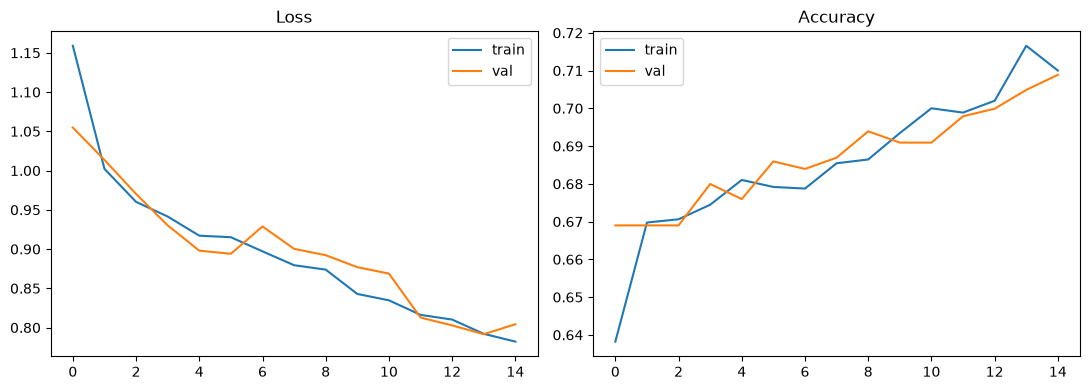

In [6]:
fig, axes = plt.subplots(1, 2, figsize = (11, 4))
axes[0].plot(history.history['loss'], label = 'train')
axes[0].plot(history.history['val_loss'], label = 'val')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(history.history['accuracy'], label = 'train')
axes[1].plot(history.history['val_accuracy'], label = 'val')
axes[1].set_title('Accuracy')
axes[1].legend()
plt.tight_layout()
plt.savefig('outputs/baseline_training_curves.png', dpi = 120)
plt.show()

This is the exact model object that was just trained - no separate TPU clone, no `clear_session()` between training and evaluation. Whatever number comes out below reflects what was actually learned.

In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose = 0)
print(f'test loss: {test_loss:.4f}')
print(f'test accuracy: {test_acc:.4f}')
print(f'majority-class baseline: {majority_baseline_acc:.4f}')

test loss: 0.7962
test accuracy: 0.7042
majority-class baseline: 0.6688


In [8]:
y_pred = np.argmax(model.predict(X_test, verbose = 0), axis = 1)

print(classification_report(y_test, y_pred, target_names = class_names, digits = 3))

              precision    recall  f1-score   support

       akiec      0.263     0.076     0.118        66
         bcc      0.312     0.340     0.326       103
         bkl      0.495     0.245     0.328       220
          df      0.000     0.000     0.000        23
         mel      0.482     0.121     0.194       223
          nv      0.755     0.963     0.847      1341
        vasc      0.000     0.000     0.000        29

    accuracy                          0.704      2005
   macro avg      0.330     0.249     0.259      2005
weighted avg      0.638     0.704     0.644      2005



/tmp/claude-1000/-home-zz-Downloads-AndroidStudioProjects/e144f78f-00b1-44af-8785-c81c517e252a/scratchpad/tfsr_venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/tmp/claude-1000/-home-zz-Downloads-AndroidStudioProjects/e144f78f-00b1-44af-8785-c81c517e252a/scratchpad/tfsr_venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/tmp/claude-1000/-home-zz-Downloads-AndroidStudioProjects/e144f78f-00b1-44af-8785-c81c517e252a/scratchpad/tfsr_venv/lib/python3.11/site-packages/skl

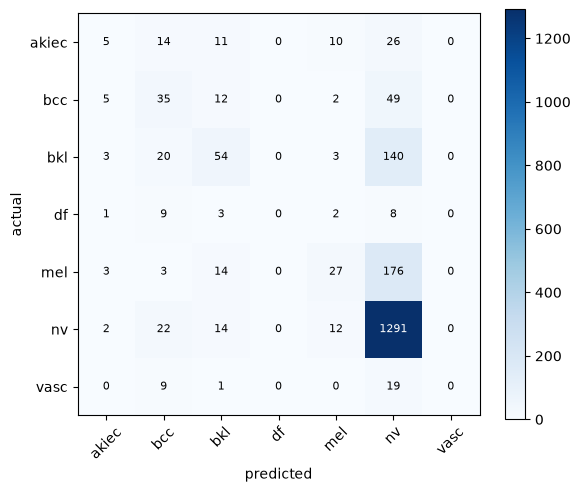

In [9]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize = (6, 5))
im = ax.imshow(cm, cmap = 'Blues')
ax.set_xticks(range(7)); ax.set_xticklabels(class_names, rotation = 45)
ax.set_yticks(range(7)); ax.set_yticklabels(class_names)
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
for i in range(7):
    for j in range(7):
        ax.text(j, i, cm[i, j], ha = 'center', va = 'center',
                color = 'white' if cm[i, j] > cm.max() / 2 else 'black', fontsize = 8)
plt.colorbar(im)
plt.tight_layout()
plt.savefig('outputs/baseline_confusion_matrix.png', dpi = 120)
plt.show()

The confusion matrix tells the real story overall accuracy hides: check how much of the diagonal is really just the `nv` cell versus actual spread across the malignant/pre-malignant classes (`mel`, `bcc`, `akiec`) - the ones a triage tool most needs to catch, and the rarest in the data.

In [10]:
os.makedirs('outputs', exist_ok = True)
results = {
    'majority_baseline_acc': float(majority_baseline_acc),
    'test_loss': float(test_loss),
    'test_acc': float(test_acc),
    'macro_f1': float(f1_score(y_test, y_pred, average = 'macro')),
    'weighted_f1': float(f1_score(y_test, y_pred, average = 'weighted')),
    'per_class_recall': {
        class_names[i]: float(r) for i, r in enumerate(
            confusion_matrix(y_test, y_pred, normalize = 'true').diagonal())
    },
    'epochs_trained': len(history.history['loss']),
    'params': int(model.count_params()),
}
with open('outputs/baseline_results.json', 'w') as f:
    json.dump(results, f, indent = 2)

model.save('outputs/baseline_cnn.keras')
results

{'majority_baseline_acc': 0.6688279301745635,
 'test_loss': 0.7961599826812744,
 'test_acc': 0.7042394280433655,
 'macro_f1': 0.2588002422174241,
 'weighted_f1': 0.6443457194681382,
 'per_class_recall': {'akiec': 0.07575757575757576,
  'bcc': 0.33980582524271846,
  'bkl': 0.24545454545454545,
  'df': 0.0,
  'mel': 0.1210762331838565,
  'nv': 0.9627143922445935,
  'vasc': 0.0},
 'epochs_trained': 15,
 'params': 9564967}